Noteboook for analysis of abm 

In [27]:
import importlib
import Model
importlib.reload(Model)
from Model import SpeciesModel
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mesa


Population plots

In [ ]:
# Dictionary of parameters
params = {"init_predators": 1,
        "init_deer" : 10,
        "height":30,     
        "width": 30,
        "seed": None,
        "predator" : 'Wolf',  # Helper attribute to avoid imports when accessing agent type
        "energy_decrease": 0.05,  # Energy decrease parameter 
        "energy_min": 0 
        }


# Creating batch runner to extract results.
results = mesa.batch_run(
    SpeciesModel,
    parameters=params,
    max_steps=1000,
    iterations=50,
    data_collection_period = 1,
    display_progress=True
)

# extract results
results_df = pd.DataFrame(results)

  0%|          | 0/50 [00:00<?, ?it/s]

KeyboardInterrupt: 

Text(0.5, 1.0, 'Population Change Over Time')

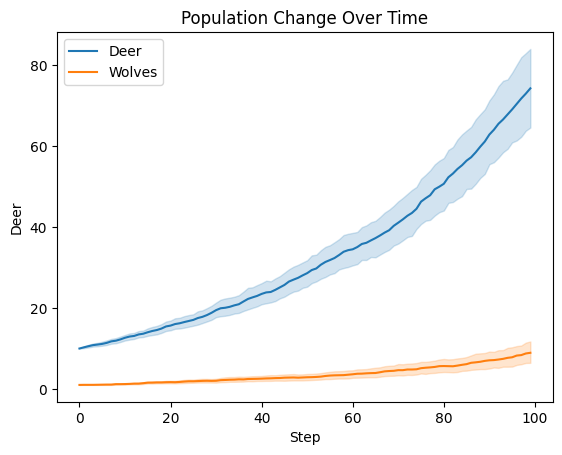

In [10]:
# Plotting the results
sns.lineplot(data=results_df, x='Step', y='Deer', label='Deer')
sns.lineplot(data=results_df, x='Step', y='Wolf', label='Wolves')
plt.title("Population Change Over Time")

## Populations Over Time

### Realistic Number of Wolves (6)

In [35]:
max_steps = 600

params3 = {
            "max_steps": max_steps,
            "init_predators": 6, # changed to 6 as more realistic )
            "init_deer": 1000,  # approx 10 deer per km^2 (1000 deer)
            "height": 10,
            "width": 10,
            "step_size": 1,  # 1 hour per step
            "yearly_sunlight_hours": 8760,
            "seed": None,
            "predator": 'Wolf',  # Helper attribute to avoid imports when accessing agent type
            "energy_decrease": 0.002,  # Energy decrease parameter 
            "pack_limit": 12,  # packs will split if too large 
            #Vegetation Parameters
            
            "veg_patch_spacing": 4,
            "sapling_density": 20,
            "tree_density": 8,
            "sapling_regrowth_prob": 1/10, # every 10 steps (10 hours) new sapling grows
            "sapling_maturation_prob": 1/20000, # sapling becomes a tree every 20000 hours (2.3 years)

            # Options to control complexity of the model
            "use_base": False,
            "use_pack_dynamics": True,
            "use_random_movement": False,
            "use_veg": True,
            "given_positions": False, # whether to use random positions or pre-chosen positions (for testing purposes)
            "use_boundary_conditions": True, # whether to use boundary conditions (reflecting off walls) or toroidal space
}

# Creating batch runner to extract results.
results2 = mesa.batch_run(
    SpeciesModel,
    parameters=params3,
    max_steps=max_steps,
    iterations=1,
    data_collection_period = 1,
    display_progress=True
)

# Extract results
results_df2 = pd.DataFrame(results2)

/tmp/ipykernel_599147/3336491667.py:33: DeprecationWarning: The `iterations` keyword argument is deprecated. Use `rng` instead (e.g. `iterations=5` is equivalent to `rng=[None] * 5`). See https://mesa.readthedocs.io/latest/migration_guide.html#batch-run
  results2 = mesa.batch_run(


  0%|          | 0/1 [00:00<?, ?it/s]

Text(0.5, 1.0, 'Population Change Over Time')

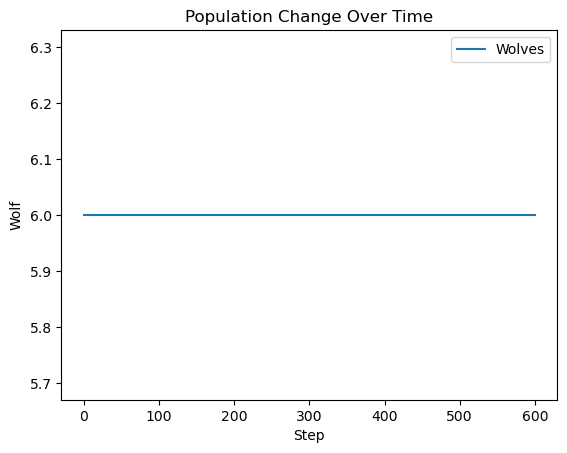

In [36]:
# Plotting the results
sns.lineplot(data=results_df2, x='Step', y='Wolf', label='Wolves')
plt.title("Population Change Over Time")

Text(0.5, 1.0, 'Population Change Over Time')

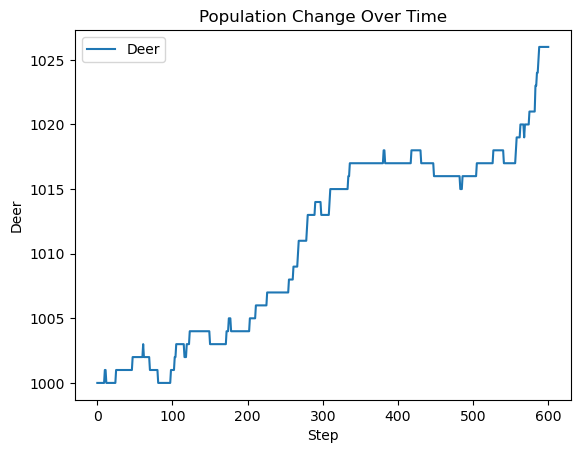

In [37]:
sns.lineplot(data=results_df2, x='Step', y='Deer', label='Deer')
plt.title("Population Change Over Time")

### Introducing more Wolves (15)

In [43]:
max_steps = 3000

wolves_15_params = {
            "max_steps": max_steps,
            "init_predators": 15, # increased to 15 to test if deer decrease is noticable
            "init_deer": 1000,  # approx 10 deer per km^2 (1000 deer)
            "height": 10,
            "width": 10,
            "step_size": 1,  # 1 hour per step
            "yearly_sunlight_hours": 5000,
            "seed": None,
            "predator": 'Wolf',  # Helper attribute to avoid imports when accessing agent type
            "energy_decrease": 0.002,  # Energy decrease parameter 
            "pack_limit": 12,  # packs will split if too large 
            #Vegetation Parameters
            
            "veg_patch_spacing": 4,
            "sapling_density": 20,
            "tree_density": 8,
            "sapling_regrowth_prob": 1/10, # every 10 steps (10 hours) new sapling grows
            "sapling_maturation_prob": 1/20000, # sapling becomes a tree every 20000 hours (2.3 years)

            # Options to control complexity of the model
            "use_base": False,
            "use_pack_dynamics": True,
            "use_random_movement": False,
            "use_veg": False,
            "given_positions": False, # whether to use random positions or pre-chosen positions (for testing purposes)
            "use_boundary_conditions": True, # whether to use boundary conditions (reflecting off walls) or toroidal space
}

# Creating batch runner to extract results.
n_iter = 5
wolves_15_results = mesa.batch_run(
    SpeciesModel,
    parameters=wolves_15_params,
    max_steps=max_steps,
    rng = [None] * n_iter,  # use random seed for n_iter iterations
    data_collection_period = 1,
    display_progress=True
)

# Extract results
wolves_15_df = pd.DataFrame(wolves_15_results)

  0%|          | 0/5 [00:00<?, ?it/s]

Text(0.5, 1.0, 'Population Change Over Time')

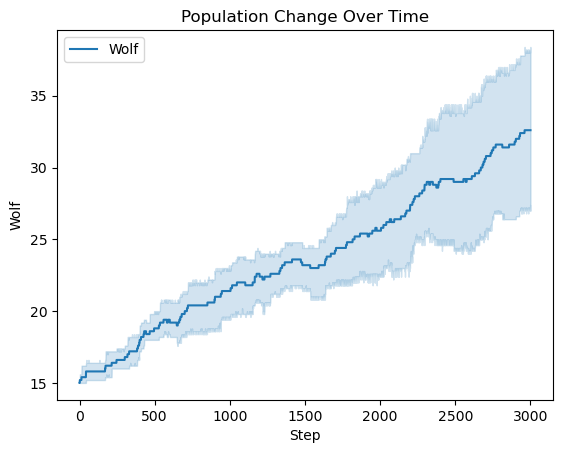

In [44]:
sns.lineplot(data=wolves_15_df, x='Step', y='Wolf', label='Wolf')
plt.title("Population Change Over Time")

Text(0.5, 1.0, 'Population Change Over Time')

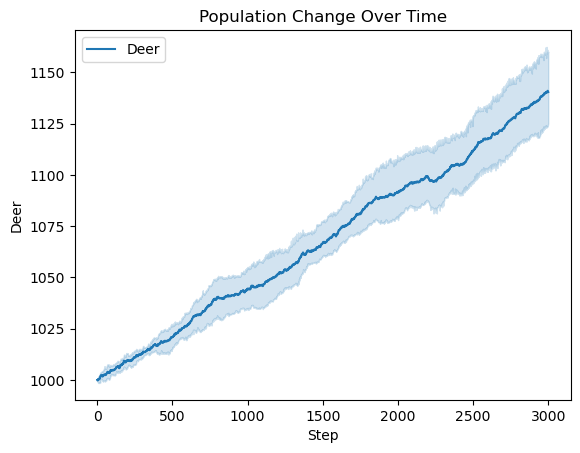

In [45]:
sns.lineplot(data=wolves_15_df, x='Step', y='Deer', label='Deer')
plt.title("Population Change Over Time")

<Axes: xlabel='Step', ylabel='Mean Wolf Energy'>

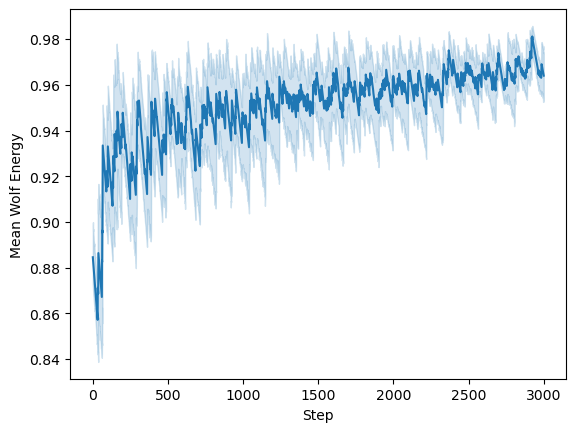

In [46]:
sns.lineplot(data=wolves_15_df, x='Step', y='Mean Wolf Energy')

<Axes: xlabel='Step', ylabel='Deer Hunted'>

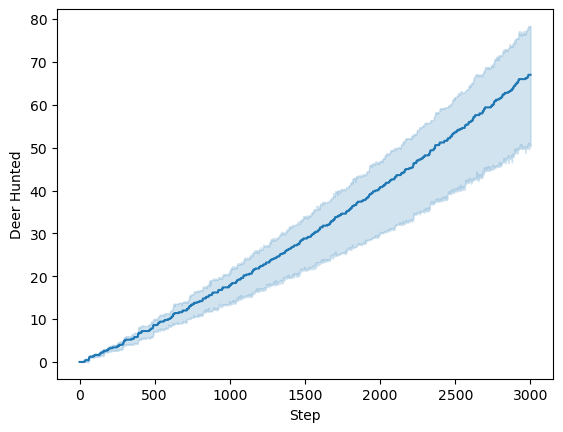

In [47]:
sns.lineplot(data=wolves_15_df, x='Step', y='Deer Hunted')


### LOADS OF DEER (167)

In [ ]:
max_steps = 600*5

loads_params = {
            "max_steps": max_steps,
            "init_predators": 167, # so many wolves!!!!!!
            "init_deer": 1000,  # approx 10 deer per km^2 (1000 deer)
            "height": 10,
            "width": 10,
            "step_size": 1,  # 1 hour per step
            "yearly_sunlight_hours": 5000,
            "seed": None,
            "predator": 'Wolf',  # Helper attribute to avoid imports when accessing agent type
            "energy_decrease": 0.002,  # Energy decrease parameter 
            "pack_limit": 12,  # packs will split if too large 
            #Vegetation Parameters
            
            "veg_patch_spacing": 4,
            "sapling_density": 20,
            "tree_density": 8,
            "sapling_regrowth_prob": 1/10, # every 10 steps (10 hours) new sapling grows
            "sapling_maturation_prob": 1/20000, # sapling becomes a tree every 20000 hours (2.3 years)

            # Options to control complexity of the model
            "use_base": False,
            "use_pack_dynamics": True,
            "use_random_movement": False,
            "use_veg": False,
            "given_positions": False, # whether to use random positions or pre-chosen positions (for testing purposes)
            "use_boundary_conditions": True, # whether to use boundary conditions (reflecting off walls) or toroidal space
}
n_iter = 1
# Creating batch runner to extract results.
loads_results = mesa.batch_run(
    SpeciesModel,
    parameters=loads_params,
    max_steps=max_steps,
    rng = [None] * n_iter,  # use random seed for n_iter iterations
    data_collection_period = 1,
    display_progress=True
    
)

# Extract results
loads_results_df = pd.DataFrame(loads_results)

  0%|          | 0/1 [00:00<?, ?it/s]

<Axes: xlabel='Step', ylabel='Deer'>

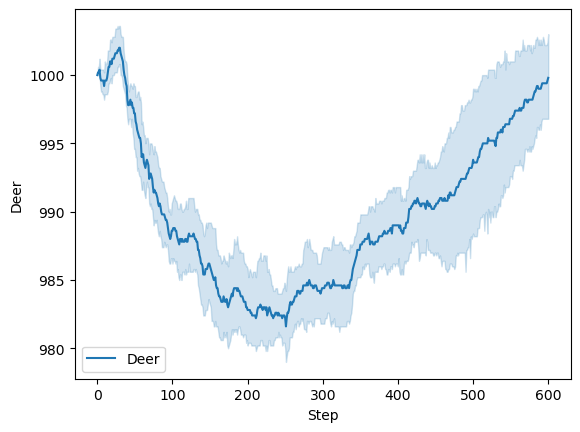

In [50]:
sns.lineplot(data=loads_results_df, x='Step', y='Deer', label='Deer')

<Axes: xlabel='Step', ylabel='Wolf'>

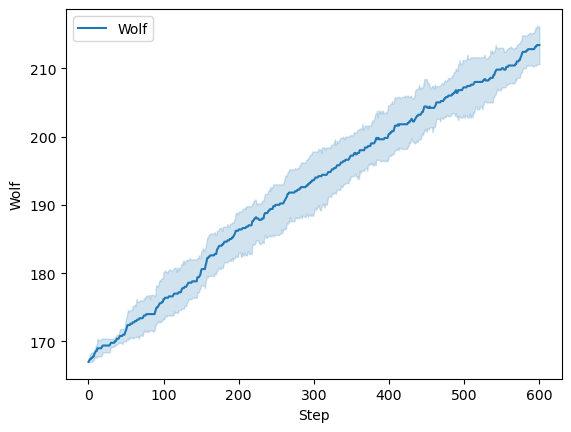

In [51]:
sns.lineplot(data=loads_results_df, x='Step', y='Wolf', label='Wolf')

<Axes: xlabel='Step', ylabel='Deer Hunted'>

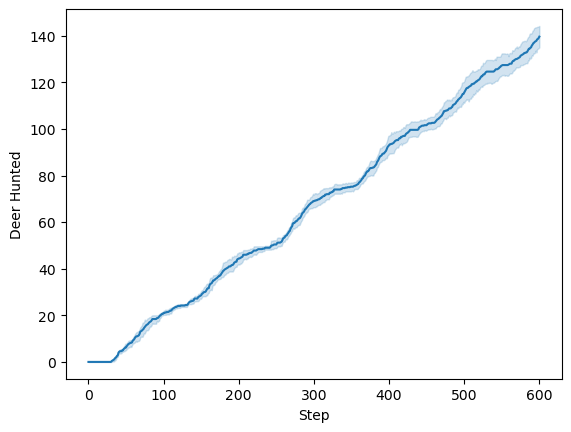

In [53]:
sns.lineplot(data=loads_results_df, x='Step', y='Deer Hunted')
